In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading dataset (with alerts or feature engineered data)
df = pd.read_csv("C:/Users/BIT/Desktop/AIML ASSIGNMENT/data/alert_results.csv")

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values(by='Date')

df.head()

,Date,Person_ID,Age,Gender,Temperature_C,Activity_Level,Water_Consumed_Liters,Consumption_scaled,Day,Month,...,City_Islamabad,City_Karachi,City_Lahore,City_Multan,City_Rawalpindi,Anomaly,Time_Index,Anomaly_Alert,Threshold_Alert,Final_Alert
0,2025-01-01,P0061,41.0,1.0,17.700000,0,1.76,0.160279,1,1,...,False,True,False,False,False,1,0,Normal,Normal,Normal
66,2025-01-01,P0016,58.0,0.0,16.800000,1,2.15,0.296167,1,1,...,False,False,False,False,True,1,66,Normal,Normal,Normal
65,2025-01-01,P0063,57.0,1.0,25.800000,0,2.31,0.351916,1,1,...,False,False,False,False,True,1,65,Normal,Normal,Normal
64,2025-01-01,P0100,55.0,0.0,28.541075,1,2.40,0.383275,1,1,...,False,False,False,False,True,1,64,Normal,Normal,Normal
63,2025-01-01,P0096,40.0,0.0,19.600000,2,2.75,0.505226,1,1,...,False,True,False,False,False,1,63,Normal,Normal,Normal


In [3]:
# Basic information
print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)

# Statistical summary
df.describe()

Dataset Shape: (32901, 25)

Columns:
 Index(['Date', 'Person_ID', 'Age', 'Gender', 'Temperature_C', 'Activity_Level',
       'Water_Consumed_Liters', 'Consumption_scaled', 'Day', 'Month', 'Year',
       'Day_of_Week', 'Rolling_Mean_3', 'Rolling_Std_3', 'Lag_1',
       'City_Islamabad', 'City_Karachi', 'City_Lahore', 'City_Multan',
       'City_Rawalpindi', 'Anomaly', 'Time_Index', 'Anomaly_Alert',
       'Threshold_Alert', 'Final_Alert'],
      dtype='str')


,Date,Age,Gender,Temperature_C,Activity_Level,Water_Consumed_Liters,Consumption_scaled,Day,Month,Year,Day_of_Week,Rolling_Mean_3,Rolling_Std_3,Lag_1,Anomaly,Time_Index
count,32901,32901.000000,31956.000000,32901.000000,32901.000000,32901.000000,32901.000000,32901.00000,32901.000000,32901.0,32901.000000,32901.000000,3.290100e+04,32901.000000,32901.000000,32901.00000
mean,2025-07-01 22:29:00.421263,40.487098,0.449274,28.520830,0.901766,2.721355,0.495246,15.73940,6.523358,2025.0,2.999331,2.721370,4.795984e-01,2.721384,0.900003,16450.00000
min,2025-01-01 00:00:00,18.000000,0.000000,15.000000,0.000000,1.300000,0.000000,1.00000,1.000000,2025.0,0.000000,1.593333,3.528172e-09,1.300000,-1.000000,0.00000
25%,2025-04-02 00:00:00,30.000000,0.000000,22.200000,0.000000,2.370000,0.372822,8.00000,4.000000,2025.0,1.000000,2.513333,2.944486e-01,2.370000,1.000000,8225.00000
50%,2025-07-02 00:00:00,41.000000,0.000000,28.541075,1.000000,2.722212,0.495544,16.00000,7.000000,2025.0,3.000000,2.720000,4.555033e-01,2.722212,1.000000,16450.00000
75%,2025-10-01 00:00:00,52.000000,1.000000,34.900000,1.000000,3.100000,0.627178,23.00000,10.000000,2025.0,5.000000,2.936667,6.402343e-01,3.100000,1.000000,24675.00000
max,2025-12-31 00:00:00,64.000000,1.000000,42.000000,2.000000,4.170000,1.000000,31.00000,12.000000,2025.0,6.000000,3.846667,1.461517e+00,4.170000,1.000000,32900.00000
std,NaN,13.024165,0.497428,7.591059,0.681151,0.536124,0.186803,8.79137,3.440856,0.0,1.997536,0.308053,2.424018e-01,0.536105,0.435890,9497.84494


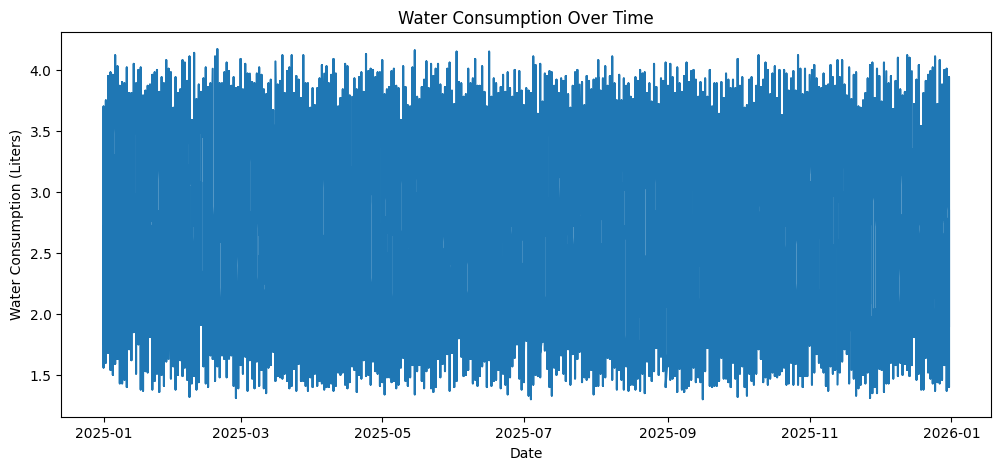

In [ ]:
#Water Consumption Over Time
plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Water_Consumed_Liters'])

plt.title("Water Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Water Consumption (Liters)")

plt.show()

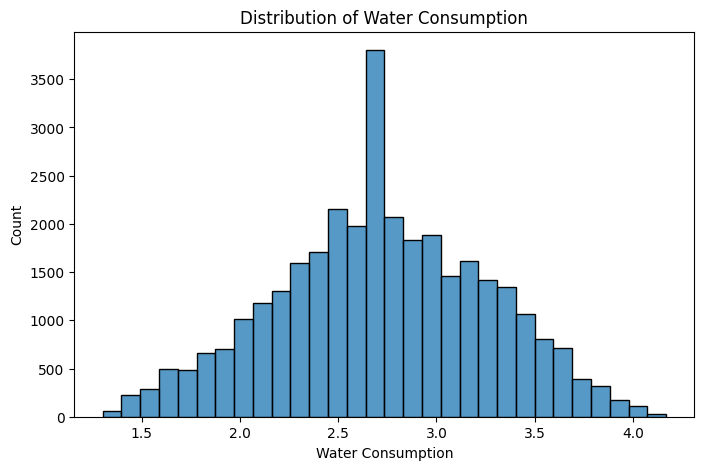

In [6]:
#Histogram
plt.figure(figsize=(8,5))

sns.histplot(df['Water_Consumed_Liters'], bins=30)

plt.title("Distribution of Water Consumption")
plt.xlabel("Water Consumption")

plt.show()

In [ ]:
#Boxplot(Outlier Visualization)

plt.figure(figsize=(8,5))

sns.boxplot(x=df['Water_Consumed_Liters'])

plt.title("Boxplot of Water Consumption")

plt.show()

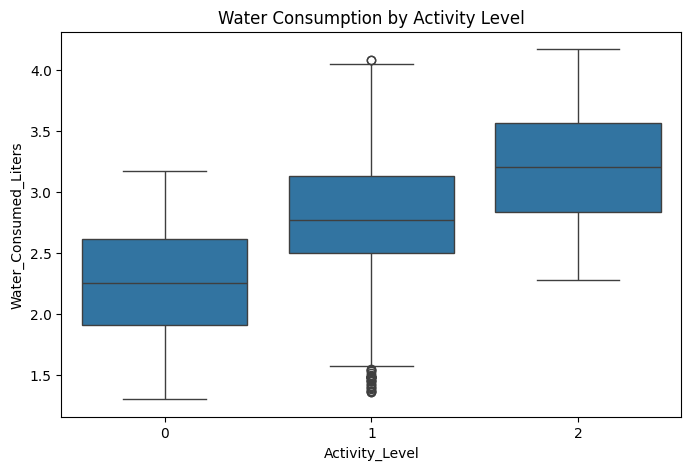

In [ ]:
#Consumption by Category(By Activity Level)

plt.figure(figsize=(8,5))

sns.boxplot(x=df['Activity_Level'], y=df['Water_Consumed_Liters'])

plt.title("Water Consumption by Activity Level")

plt.show()

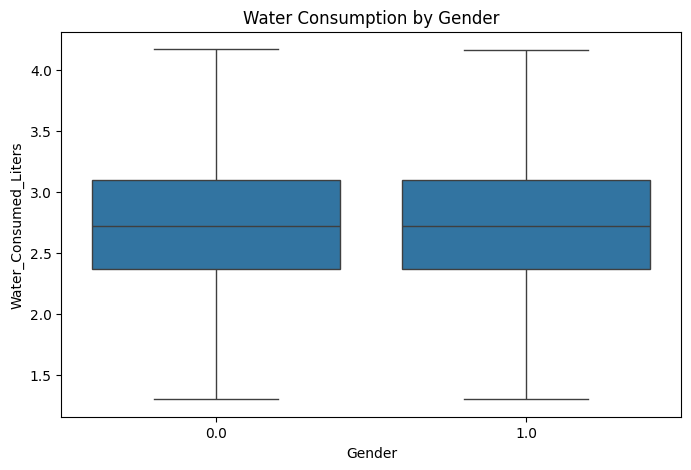

In [8]:
#By Gender
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Gender'], y=df['Water_Consumed_Liters'])

plt.title("Water Consumption by Gender")

plt.show()

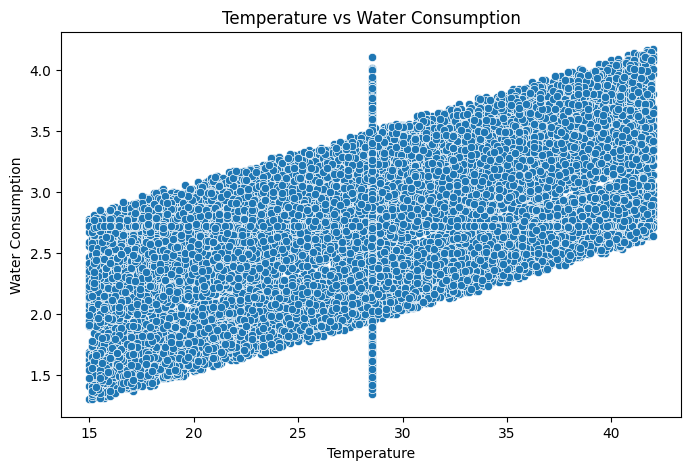

In [9]:
#Temperature vs Consumption(Scatter Plot)

plt.figure(figsize=(8,5))

sns.scatterplot(x=df['Temperature_C'], y=df['Water_Consumed_Liters'])

plt.title("Temperature vs Water Consumption")

plt.xlabel("Temperature")
plt.ylabel("Water Consumption")

plt.show()

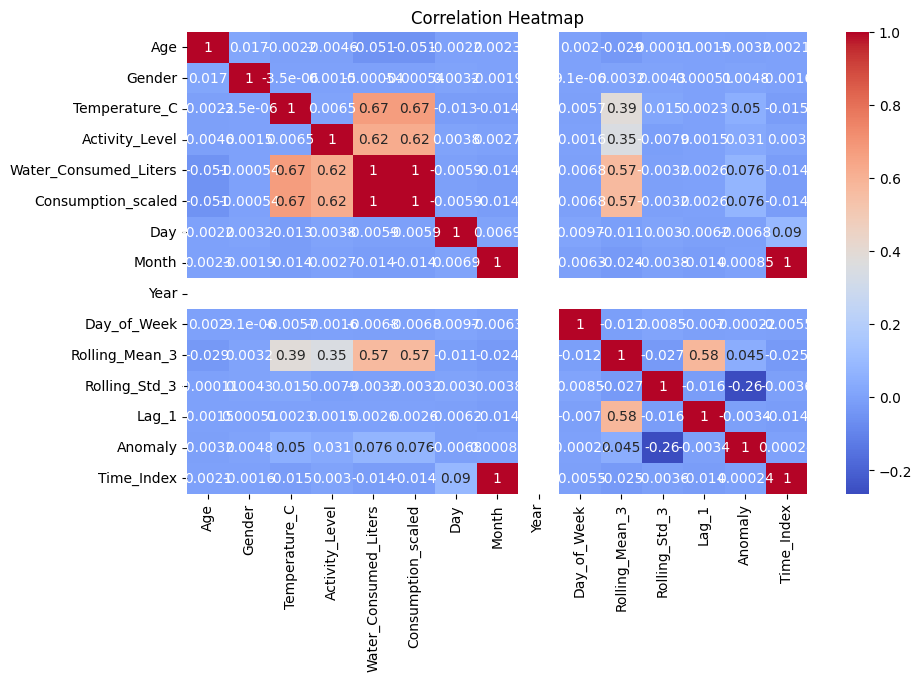

In [11]:
# Correlation Heatmap 

plt.figure(figsize=(10,6))

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

correlation = numeric_df.corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

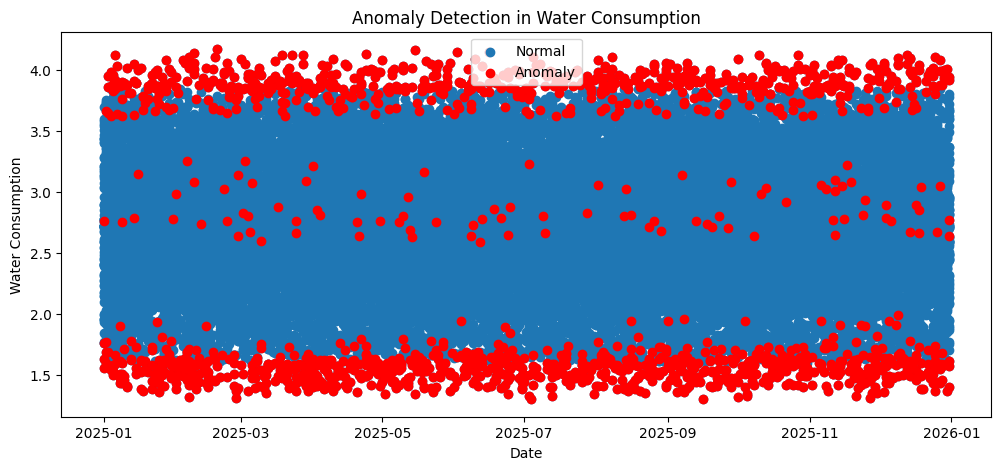

In [ ]:
# Anamoly Visualization

if 'Anomaly' in df.columns:
    plt.figure(figsize=(12,5))
    
    plt.scatter(df['Date'], df['Water_Consumed_Liters'], label='Normal')
    
    anomalies = df[df['Anomaly'] == -1]
    plt.scatter(anomalies['Date'], anomalies['Water_Consumed_Liters'], color='red', label='Anomaly')
    
    plt.title("Anomaly Detection in Water Consumption")
    plt.xlabel("Date")
    plt.ylabel("Water Consumption")
    plt.legend()
    
    plt.show()

In [14]:
#Printing Key Insights

print("=== Key Insights ===\n")

print("1. Average Water Consumption:", df['Water_Consumed_Liters'].mean())

print("\n2. Maximum Consumption:", df['Water_Consumed_Liters'].max())

print("\n3. Minimum Consumption:", df['Water_Consumed_Liters'].min())

print("\n4. Correlation with Temperature:", df['Water_Consumed_Liters'].corr(df['Temperature_C']))

=== Key Insights ===

1. Average Water Consumption: 2.7213553388001968

2. Maximum Consumption: 4.17

3. Minimum Consumption: 1.3

4. Correlation with Temperature: 0.6729755324924472
